In [9]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv('gdp.csv')
df.head()

,Country Name,Country Code,Year,Value
0,Arab World,ARB,1968,2.576068e+10
1,Arab World,ARB,1969,2.843420e+10
2,Arab World,ARB,1970,3.138550e+10
3,Arab World,ARB,1971,3.642691e+10
4,Arab World,ARB,1972,4.331606e+10


In [10]:
df.isna().sum()

Country Name    0
Country Code    0
Year            0
Value           0
dtype: int64

## 1) How many unique Countries Data we're having in the dataset?

In [11]:
df['Country Name'].nunique() # we are having data of 256 countries

256

## 2) How many years of Data we're having for India

In [12]:
df[df['Country Name'] == 'India']['Year'].count() # we are having 57 years of data for india from 1960 to 2016

57

## 3) Whats the world GDP in 1969?

In [13]:
df.info()
df[df['Year']==1969]['Value'].sum()  # so the world gdp in 1969 was 19,577,201,579,296.54 -> 19.5 trillion

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11507 entries, 0 to 11506
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  11507 non-null  object 
 1   Country Code  11507 non-null  object 
 2   Year          11507 non-null  int64  
 3   Value         11507 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 359.7+ KB


19577201579296.54

## 4) Whats the % of GDP growth of India in Year 1994 (*as compare to 1993)?

In [14]:
df[(df['Country Name']=='India')&(df['Year'].isin([1993,1994]))] ## to find value wise
df[(df['Country Name']=='India')&(df['Year'].between(1990,2000))] ## to slice value wise 
## percent calculation
gdp_1993 = df[(df['Country Name']=='India')&(df['Year'].isin([1993]))]['Value'].values[0]
gdp_1994 = df[(df['Country Name']=='India')&(df['Year'].isin([1994]))]['Value'].values[0]

percent = ((gdp_1994-gdp_1993)/gdp_1993)*100
percent 
### therefore 17% of gdp growth 


17.178748210146075

# Tasks

### 1) Find GDP Growth of India from 1960 - 2016
### 2) Create a new columns named as GDP which shows the GDP growth of each country for that year
### 3) Create a graph of GDP Growth of India from 1960 - 2016

##### Task 1

In [15]:
India_gdp = df[df['Country Name']=='India']
gdp_1960 = India_gdp[India_gdp['Year']==1960]['Value'].values[0]
gdp_2016 = India_gdp[India_gdp['Year']==2016]['Value'].values[0]

growth = ((gdp_2016-gdp_1960)/gdp_1960)*100
growth


6096.072762594173

#### Task 2

In [16]:
lst = []
prev_years = {}

def gdpFinder( value , prev_val):
    return ((value-prev_val)/prev_val)*100

for i in range(len(df)):
    year = df['Year'][i]
    country = df['Country Name'][i]
    c_val = df['Value'][i]
    if year<=df[df['Country Name']==country]['Year'].min():
        lst.append(0)
        prev_years[country] = year
    else:
        p_val = df[(df['Country Name']==country)&(df['Year']==prev_years[country])]['Value'].values[0]
        prev_years[country] = year
        lst.append(gdpFinder(c_val,p_val))

df['GDP_Growth(%)'] = lst

In [17]:
## easy fast approach 
df = df.sort_values(['Country Name' , 'Year'])
df['GDP_Growth(%)']=df.groupby(by="Country Name")['Value'].pct_change()*100

In [18]:
df[df['Country Name']=='India']['GDP_Growth(%)'].mean() ## from 1960 to 2016 India shown 8% of annual growth in gdp

8.010818928223234

In [19]:
df.sort_index(inplace=True)
df

,Country Name,Country Code,Year,Value,GDP_Growth(%)
0,Arab World,ARB,1968,2.576068e+10,NaN
1,Arab World,ARB,1969,2.843420e+10,10.378298
2,Arab World,ARB,1970,3.138550e+10,10.379387
3,Arab World,ARB,1971,3.642691e+10,16.062864
4,Arab World,ARB,1972,4.331606e+10,18.912246
...,...,...,...,...,...
11502,Zimbabwe,ZWE,2012,1.424249e+10,17.721604
11503,Zimbabwe,ZWE,2013,1.545177e+10,8.490639
11504,Zimbabwe,ZWE,2014,1.589105e+10,2.842915
11505,Zimbabwe,ZWE,2015,1.630467e+10,2.602840


In [20]:
df_grow = df.groupby('Country Name')['GDP_Growth(%)'].mean()

In [21]:
df_grow = pd.DataFrame(df_grow)

In [22]:
df_grow.nlargest(10 , columns='GDP_Growth(%)')

,GDP_Growth(%)
Country Name,
Cayman Islands,216.761448
Nauru,22.947011
Equatorial Guinea,22.741644
Iraq,18.528494
Oman,18.028124
Qatar,17.732720
Switzerland,16.452862
Cambodia,15.296994
Myanmar,15.097340


<Axes: xlabel='Country Name'>

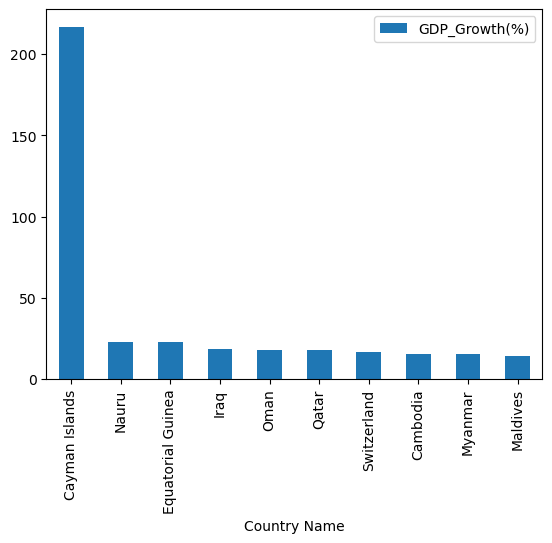

In [23]:
df_grow.sort_values(by='GDP_Growth(%)' , ascending=False).head(10).plot(kind='bar')

##### -> graph above shows top 10 fastest growing economies

#### Task 3

In [24]:
df_grow.reset_index(inplace=True)

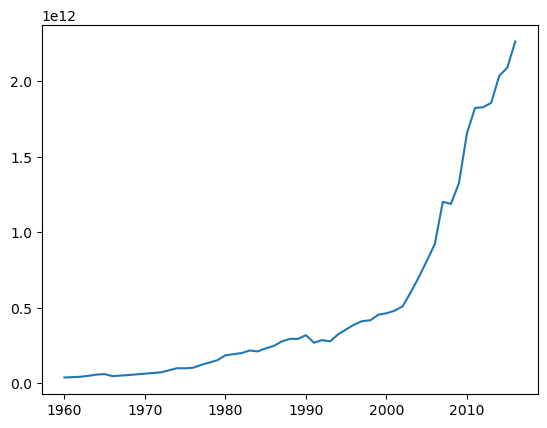

In [25]:
plt.plot(df[df['Country Name']=='India']['Year'] ,df[df['Country Name']=='India']['Value'] )